In [1]:
import numpy as np
import pandas as pd
import math
import heapq

In [2]:
a = pd.read_csv("./datasets/a280.csv")
a = pd.read_csv("./minidatasets/minitsp.csv")
points = np.array(a[['x','y']])
inputsize = len(points)

In [3]:
# distance matrix 만들기
diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]
distance_matrix = np.sqrt(np.sum(diff ** 2, axis=-1))

In [4]:
# MST 찾기( 프림 알고리즘 사용)
visited = [False] * len(points)
minheap = []
mstgraph = np.full( ( inputsize, inputsize ), np.inf)

# 0 추가
for x in range(inputsize):
    heapq.heappush(minheap, ( distance_matrix[0][x] , 0, x ) )
visited[ 0 ] = True

while minheap:
    Weight, From, To = heapq.heappop( minheap )
    if not visited[To]:
        visited[To] = True
        mstgraph[ From, To ] = Weight
        mstgraph[ To, From ] = Weight
        for x in range(inputsize):
            next_to, next_weight = x, distance_matrix[To][x]
            if not visited[ next_to ]:
                heapq.heappush( minheap, ( next_weight, To, next_to ) )

mstgraph

array([[        inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,  7.07106781,         inf,         inf,         inf,
                inf,  8.06225775,         inf,         inf,         inf],
       [        inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
         8.54400375,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,  9.05538514,         inf],
       [        inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,   

In [5]:
# 홀수 degree 찾기
oddmat = np.full( ( inputsize, inputsize ), np.inf)

finite_mask = np.isfinite(mstgraph)              # inf가 아닌 값은 True
finite_count_per_row = finite_mask.sum(axis=1) # 각 행마다 inf가 아닌 값의 개수
odd_rows = np.where(finite_count_per_row % 2 == 1)[0]  # 개수가 홀수인 행 인덱스

print(odd_rows.tolist())

[4, 7, 9, 10, 14, 15, 16, 18, 20, 28]


In [6]:
# minimum weight perfect matching Blossom 알고리즘
dual = np.full( ( inputsize, inputsize ), np.inf)
primal = np.full( ( inputsize, inputsize ), np.inf)

print(distance_matrix[np.ix_(odd_rows, odd_rows)])
len(distance_matrix[np.ix_(odd_rows, odd_rows)])

[[ 0.         33.24154028 14.2126704  11.18033989 14.56021978 16.2788206
  14.76482306 31.90611227 25.05992817 25.45584412]
 [33.24154028  0.         45.61797891 23.70653918 46.27094121 29.69848481
  39.20459157 52.20153254 36.89173349 30.41381265]
 [14.2126704  45.61797891  0.         21.9317122  15.8113883  20.02498439
  24.08318916 38.83297568 23.70653918 27.89265136]
 [11.18033989 23.70653918 21.9317122   0.         25.70992026 10.
  23.43074903 40.31128874 20.02498439 17.4642492 ]
 [14.56021978 46.27094121 15.8113883  25.70992026  0.         29.68164416
  11.40175425 23.19482701 36.76955262 38.83297568]
 [16.2788206  29.69848481 20.02498439 10.         29.68164416  0.
  30.8058436  48.01041554 10.04987562  9.21954446]
 [14.76482306 39.20459157 24.08318916 23.43074903 11.40175425 30.8058436
   0.         17.20465053 39.8246155  39.8246155 ]
 [31.90611227 52.20153254 38.83297568 40.31128874 23.19482701 48.01041554
  17.20465053  0.         56.93856338 57.00877125]
 [25.05992817 36.8

10

In [7]:
# (u, v, weight)
next_Id = len( distance_matrix ) + 1

class node:
    def __init__(self, Id, indices):
        self.nid = Id
        self.tid = Id # 필요한가?? 흠
        self.dist = [ (to, distance_matrix[Id][to]) for to in indices if to != Id]
        self.dual = 0
        self.matching = None
        self.visited = False
        self.label = None
        
    def is_blossom(self):
        return False
    
    def distance(self, v):
        for i, j in self.dist:
            if i == v.nid:
                return j
        return -1
                
    def slack(self, v):
        d = self.distance(v)
        return d - v.dual - self.dual

class blossom(node):
    def __init__(self, cycle):
        self.nid = next_Id
        next_Id += 1

        self.leaves = cycle
        
    def is_blossom(self):
        return True

    def distance(self, v):
        m = np.inf
        for x in self.cycle:
            m = min( m, x.distance(v) )
        return m

    def slack(self, v):
        d = self.distance(v)
        return d - v.dual - self.dual


class tree: #사실 트리임
    def __init__(self, G ,indices=None):
        if indices is not None:
            self.nodes = [ node( Id, indices ) for Id in indices ]
            self.root = None
    def add_node(self, u):
        self.nodes.append(u)
    def add_edge(self, e):
        u,v,w = e
        u.dist.append( (v.Id, w) )
    def distance(self, u, v):
        return u.distance(v)
    def slack(self, u, v):
        return u.slack(v)
    def tightnode(self,u):
        return [ node for node in self.nodes if self.slack(u, node) == 0 ]



class blossomgraph:
    def __init__(self, indices):
        self.nodes = [ node( Id, indices ) for Id in indices ]
        self.tree = None
        # self.edges = [ ( u, v, distance_matrix[u, v]) for u in indices for v in indices if u < v ]
    def distance(self, u, v):
        return u.distance(v)
    def slack(self, u, v):
        return u.slack(v)
    def tightnode(self,u):
        return [ node for node in self.nodes if self.slack(u, node) == 0 ]
    def mktree(self, root):
        return
        
    def GROW(self, u, v):
        v.label = not u.label
        v.visited = True
        v.matching.label = u.label
        v.matching.visited = True
        return
    def AUGMENT(self,u,v):
        return
    def SHRINK(self,u,v):
        return
    def EXPAND(self,u,v):
        return
    def dualupdate():
        return

    def find_min_weight_matching(self):
        #init dual - greedy
        # 최소거리의 절반으로 먼저 셋팅함
        for node in self.nodes:
            m = np.inf
            for To in self.nodes:
                if To == node:
                    continue
                if m > node.distance(To):
                    m = node.distance(To)
            node.dual = m / 2
            
        # 그리디하게 최대화해두자
        for node in self.nodes:
            m = np.inf
            closestnode = node
            for To in self.nodes:
                if To == node:
                    continue
                if m > node.slack(To):
                    m = node.slack(To)
                    closestnode = To
            node.dual += m
            if node.matching == None and closestnode.matching ==None:
                node.matching = closestnode
                closestnode.matching = node

        def init_nodes():
            for node in self.nodes:
                node.label = None
                node.visited = False


        # anode # 매칭 없는 짜바리 찐따임
        # bfs(anode) #anode 부터 bfs 돌아버림 돌때, tight 한거만.
        queue = []
        init_nodes()
        for node in self.nodes:
            if node.matching is not None:
                queue.append( node )
                node.visited = True
                node.label = True # +
                break

        while len(queue):
            curnode = queue[0]
            for node in self.tightnode(curnode):
                if not node.visited:
                    queue.append(node)
                    node.visited=True
                    node.label = not curnode.label
                else:
                    #싸이클인디요?
                    None
            

            
            del queue[0]
            
            
        
        
        return

g = blossomgraph(odd_rows)
a = g.nodes[3]
b = g.nodes[7]
g.find_min_weight_matching()


31


In [8]:
# 오일러 회로 찾기
# np.where( odd_rows == 1 )[0][0]
for x in range( len( g.nodes ) ):
    if g.nodes[x].matching != None:
        print( g.nodes[x].nid, g.nodes[x].matching.nid , g.nodes[x] == g.nodes[x].matching.matching )

4 10 True
10 4 True
14 16 True
16 14 True
20 28 True
28 20 True


In [9]:
for x in g.tightnode(a):
    print(x.nid)

4
7
15


In [10]:
# # shortcutting
# for i in g.nodes:
#     for j in g.nodes:
#         if i == j:
#             continue
#         print( i.nid, j.nid, g.slack(i,j))

In [11]:
# import matplotlib.pyplot as plt
# import networkx as nx

# # position 딕셔너리 생성
# pos = {node.nid: points[node.nid] for node in g.nodes}

# plt.figure(figsize=(10,10))

# for node in g.nodes:
#     x, y = pos[node.nid]
#     radius = node.dual
#     circle = plt.Circle((x, y), radius, color='b', fill=False, alpha=0.5)
#     plt.gca().add_patch(circle)
#     plt.plot(x, y, 'ro')  # 노드 위치 표시

# plt.title('Graph nodes with dual value as radius')
# plt.xlabel('X')
# plt.ylabel('Y')
# plt.axis('equal')
# plt.grid(True)
# plt.show()


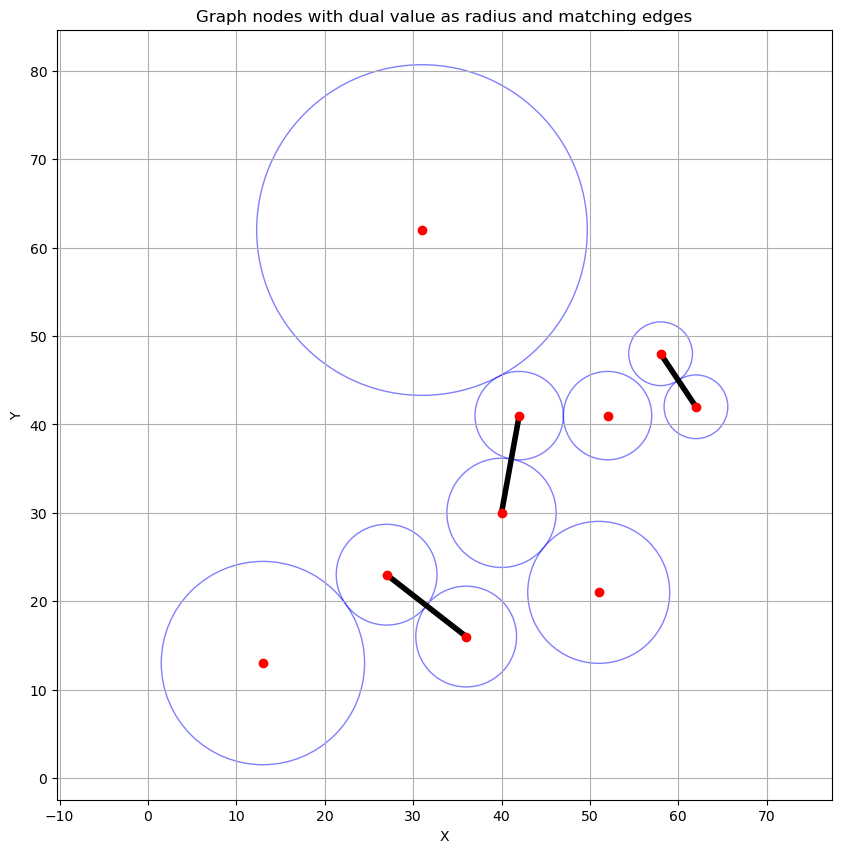

In [12]:
import matplotlib.pyplot as plt

# # position 딕셔너리 생성
# pos = {node.nid: points[node.nid] for node in g.nodes}

# plt.figure(figsize=(10,10))

# # 1. 매칭 간선 먼저 그리기 (두꺼운 선)
# drawn = set()
# for node in g.nodes:
#     match = node.matching
#     # 매칭이 있고, 아직 그리지 않은 쌍만 그림
#     if match is not None and (node.nid, match.nid) not in drawn and (match.nid, node.nid) not in drawn:
#         x1, y1 = pos[node.nid]
#         x2, y2 = pos[match.nid]
#         plt.plot([x1, x2], [y1, y2], color='k', linewidth=4)  # 두꺼운 검은선
#         drawn.add((node.nid, match.nid))

# # 2. 각 노드의 원과 점 그리기
# for node in g.nodes:
#     x, y = pos[node.nid]
#     radius = node.dual
#     circle = plt.Circle((x, y), radius, color='b', fill=False, alpha=0.5)
#     plt.gca().add_patch(circle)
#     plt.plot(x, y, 'ro')  # 노드 위치 표시

# plt.title('Graph nodes with dual value as radius and matching edges')
# plt.xlabel('X')
# plt.ylabel('Y')
# plt.axis('equal')
# plt.grid(True)
# plt.show()

def visualize():
    # position 딕셔너리 생성
    pos = {node.nid: points[node.nid] for node in g.nodes}
    
    plt.figure(figsize=(10,10))
    
    # 1. 매칭 간선 먼저 그리기 (두꺼운 선)
    drawn = set()
    for node in g.nodes:
        match = node.matching
        # 매칭이 있고, 아직 그리지 않은 쌍만 그림
        if match is not None and (node.nid, match.nid) not in drawn and (match.nid, node.nid) not in drawn:
            x1, y1 = pos[node.nid]
            x2, y2 = pos[match.nid]
            plt.plot([x1, x2], [y1, y2], color='k', linewidth=4)  # 두꺼운 검은선
            drawn.add((node.nid, match.nid))
    
    # 2. 각 노드의 원과 점 그리기
    for node in g.nodes:
        x, y = pos[node.nid]
        radius = node.dual
        circle = plt.Circle((x, y), radius, color='b', fill=False, alpha=0.5)
        plt.gca().add_patch(circle)
        plt.plot(x, y, 'ro')  # 노드 위치 표시
    
    plt.title('Graph nodes with dual value as radius and matching edges')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis('equal')
    plt.grid(True)
    plt.show()

visualize()